# 🌐 Website Traffic Analysis
**InternSpark Data Analyst Project**

---
### 📌 Objective
To analyse website traffic data and extract actionable business insights using Python.

### 🛠️ Tools Used
- Python (Pandas, NumPy, Matplotlib, Seaborn)
- Google Colab
- Dataset: Website Traffic Dataset (Kaggle)

## 📥 STEP 1 — Upload Dataset
Run this cell and click **Choose Files** to upload your `website_traffic.csv` file.

> **Download the dataset first from Kaggle:**
> https://www.kaggle.com/datasets/anthonytherrien/website-traffic

In [4]:
from google.colab import files
uploaded = files.upload()

Saving website_traffic.csv.csv to website_traffic.csv.csv


## 📦 STEP 2 — Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 12

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 📂 STEP 3 — Load the Dataset

In [8]:
df = pd.read_csv("website_wata.csv")

print('✅ Dataset loaded successfully!')
print(f'📊 Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}')
df.head()

✅ Dataset loaded successfully!
📊 Total Rows: 2000 | Total Columns: 7


,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Previous Visits,Conversion Rate
0,5,11.051381,0.230652,Organic,3.890460,3,1.0
1,4,3.429316,0.391001,Social,8.478174,0,1.0
2,4,1.621052,0.397986,Organic,9.636170,2,1.0
3,5,3.629279,0.180458,Organic,2.071925,3,1.0
4,5,4.235843,0.291541,Paid,1.960654,5,1.0


## 🔍 STEP 4 — Explore the Data

In [9]:
print("=== DATASET INFO ===")
df.info()

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Page Views        2000 non-null   int64  
 1   Session Duration  2000 non-null   float64
 2   Bounce Rate       2000 non-null   float64
 3   Traffic Source    2000 non-null   object 
 4   Time on Page      2000 non-null   float64
 5   Previous Visits   2000 non-null   int64  
 6   Conversion Rate   2000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 109.5+ KB


In [10]:
print("=== STATISTICAL SUMMARY ===")
df.describe()

=== STATISTICAL SUMMARY ===


,Page Views,Session Duration,Bounce Rate,Time on Page,Previous Visits,Conversion Rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.950500,3.022045,0.284767,4.027439,1.978500,0.982065
std,2.183903,3.104518,0.159781,2.887422,1.432852,0.065680
min,0.000000,0.003613,0.007868,0.068515,0.000000,0.343665
25%,3.000000,0.815828,0.161986,1.935037,1.000000,1.000000
50%,5.000000,1.993983,0.266375,3.315316,2.000000,1.000000
75%,6.000000,4.197569,0.388551,5.414627,3.000000,1.000000
max,14.000000,20.290516,0.844939,24.796182,9.000000,1.000000


In [11]:
print("=== COLUMN NAMES ===")
print(df.columns.tolist())

print("\n=== UNIQUE VALUES IN KEY COLUMNS ===")
for col in df.select_dtypes(include="object").columns:
    print(f"{col}: {df[col].nunique()} unique -> {list(df[col].unique()[:5])}")

=== COLUMN NAMES ===
['Page Views', 'Session Duration', 'Bounce Rate', 'Traffic Source', 'Time on Page', 'Previous Visits', 'Conversion Rate']

=== UNIQUE VALUES IN KEY COLUMNS ===
Traffic Source: 5 unique -> ['Organic', 'Social', 'Paid', 'Direct', 'Referral']


## 🧹 STEP 5 — Data Cleaning

In [12]:
print("=== MISSING VALUES ===")
print(df.isnull().sum())

print(f"\n=== DUPLICATE ROWS ===")
print(f"Duplicates found: {df.duplicated().sum()}")

df = df.dropna()
df = df.drop_duplicates()

# Detect and parse date column
date_cols = [c for c in df.columns if "date" in c.lower()]
if date_cols:
    df[date_cols[0]] = pd.to_datetime(df[date_cols[0]])
    df["Year"]       = df[date_cols[0]].dt.year
    df["Month"]      = df[date_cols[0]].dt.month
    df["Month Name"] = df[date_cols[0]].dt.strftime("%b")
    df["Day of Week"] = df[date_cols[0]].dt.day_name()
    print(f"\n✅ Date column detected: {date_cols[0]}")

# Auto-detect key columns
source_col   = next((c for c in df.columns if any(k in c.lower() for k in ["source","channel","medium","traffic"])), None)
pv_col       = next((c for c in df.columns if "page" in c.lower() and "view" in c.lower()), None)
session_col  = next((c for c in df.columns if "session" in c.lower()), None)
bounce_col   = next((c for c in df.columns if "bounce" in c.lower()), None)
duration_col = next((c for c in df.columns if "duration" in c.lower() or ("time" in c.lower() and "date" not in c.lower())), None)
conv_col     = next((c for c in df.columns if "conver" in c.lower()), None)
device_col   = next((c for c in df.columns if any(k in c.lower() for k in ["device","country","location","region"])), None)

print("\n=== AUTO-DETECTED COLUMNS ===")
print(f"  Traffic Source : {source_col}")
print(f"  Page Views     : {pv_col}")
print(f"  Sessions       : {session_col}")
print(f"  Bounce Rate    : {bounce_col}")
print(f"  Duration       : {duration_col}")
print(f"  Conversion     : {conv_col}")
print(f"  Device/Country : {device_col}")

metric_col = pv_col or session_col or df.select_dtypes(include="number").columns[0]
group_col  = source_col or df.select_dtypes(include="object").columns[0]

print(f"\n✅ Data cleaned! Final shape: {df.shape}")

=== MISSING VALUES ===
Page Views          0
Session Duration    0
Bounce Rate         0
Traffic Source      0
Time on Page        0
Previous Visits     0
Conversion Rate     0
dtype: int64

=== DUPLICATE ROWS ===
Duplicates found: 0

=== AUTO-DETECTED COLUMNS ===
  Traffic Source : Traffic Source
  Page Views     : Page Views
  Sessions       : Session Duration
  Bounce Rate    : Bounce Rate
  Duration       : Session Duration
  Conversion     : Conversion Rate
  Device/Country : None

✅ Data cleaned! Final shape: (2000, 7)


## 📊 STEP 6 — Data Visualizations & Analysis

### 📈 Chart 1 — Traffic by Source

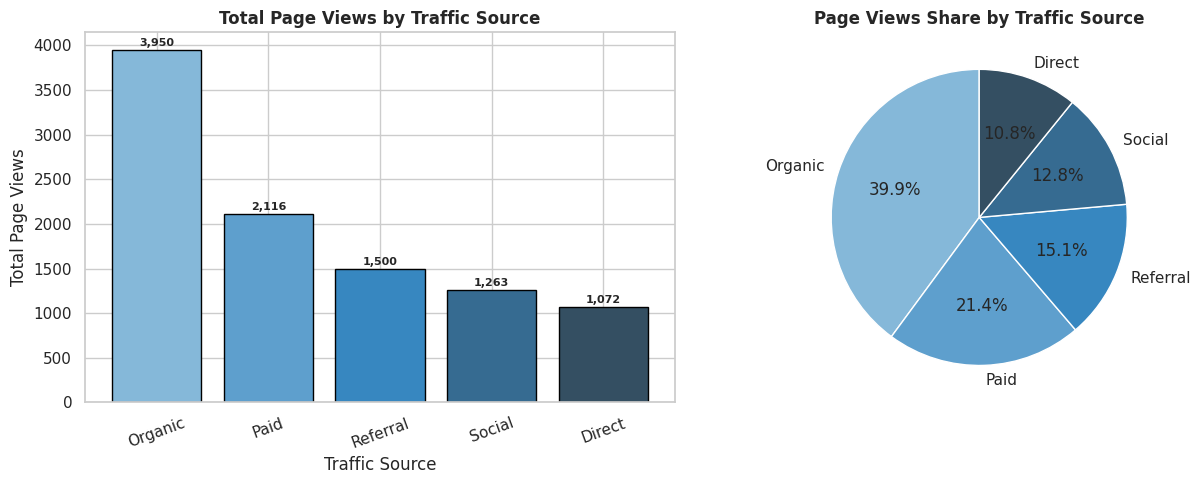

📌 Insight — Page Views by Traffic Source:
   Organic: 3,950 (39.9%)
   Paid: 2,116 (21.4%)
   Referral: 1,500 (15.1%)
   Social: 1,263 (12.8%)
   Direct: 1,072 (10.8%)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

source_traffic = df.groupby(group_col)[metric_col].sum().sort_values(ascending=False)
colors = sns.color_palette("Blues_d", len(source_traffic))

axes[0].bar(source_traffic.index, source_traffic.values, color=colors, edgecolor="black")
axes[0].set_title(f"Total {metric_col} by {group_col}", fontweight="bold")
axes[0].set_xlabel(group_col)
axes[0].set_ylabel(f"Total {metric_col}")
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=20)
for i, v in enumerate(source_traffic.values):
    axes[0].text(i, v + max(source_traffic.values)*0.01, f"{v:,.0f}", ha="center", fontsize=8, fontweight="bold")

axes[1].pie(source_traffic.values, labels=source_traffic.index, autopct="%1.1f%%", startangle=90, colors=colors)
axes[1].set_title(f"{metric_col} Share by {group_col}", fontweight="bold")

plt.tight_layout()
plt.savefig("chart1_traffic_by_source.png", dpi=150)
plt.show()

print(f"📌 Insight — {metric_col} by {group_col}:")
for src, val in source_traffic.items():
    print(f"   {src}: {val:,.0f} ({val/source_traffic.sum()*100:.1f}%)")

### 📈 Chart 2 — Monthly Traffic Trend

In [14]:
if "Month" in df.columns and "Year" in df.columns:
    monthly = df.groupby(["Year","Month"])[metric_col].sum().reset_index()
    plt.figure(figsize=(14, 5))
    for year in sorted(df["Year"].unique()):
        data = monthly[monthly["Year"] == year]
        plt.plot(data["Month"], data[metric_col], marker="o", label=str(year), linewidth=2)
    plt.title(f"Monthly {metric_col} Trend by Year", fontsize=15, fontweight="bold")
    plt.xlabel("Month")
    plt.ylabel(f"Total {metric_col}")
    plt.xticks(range(1,13), ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
    plt.legend(title="Year")
    plt.tight_layout()
    plt.savefig("chart2_monthly_trend.png", dpi=150)
    plt.show()
    best = monthly.groupby("Month")[metric_col].mean().idxmax()
    months_list = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
    print(f"📌 Insight: Best traffic month on average: {months_list[best-1]}")
else:
    print("⚠️ No date column found — skipping monthly trend chart.")

⚠️ No date column found — skipping monthly trend chart.


### 📈 Chart 3 — Bounce Rate by Source

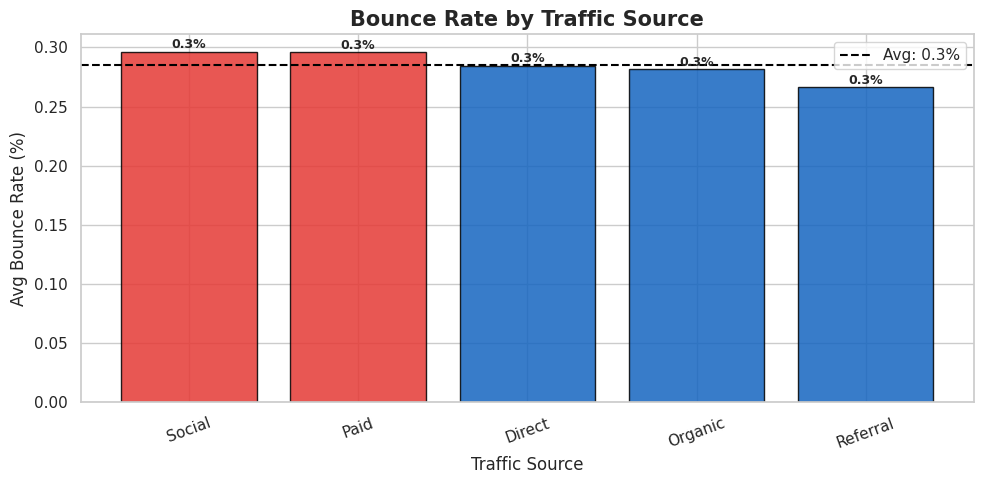

📌 Insight: Avg bounce rate = 0.3%. Red bars are above average — need improvement.


In [15]:
if bounce_col:
    bounce_by_source = df.groupby(group_col)[bounce_col].mean().sort_values(ascending=False)
    avg_bounce = bounce_by_source.mean()
    plt.figure(figsize=(10, 5))
    colors = ["#e53935" if v > avg_bounce else "#1565c0" for v in bounce_by_source.values]
    bars = plt.bar(bounce_by_source.index, bounce_by_source.values, color=colors, edgecolor="black", alpha=0.85)
    plt.axhline(avg_bounce, color="black", linestyle="--", linewidth=1.5, label=f"Avg: {avg_bounce:.1f}%")
    plt.title(f"Bounce Rate by {group_col}", fontsize=15, fontweight="bold")
    plt.xlabel(group_col)
    plt.ylabel("Avg Bounce Rate (%)")
    plt.setp(plt.gca().xaxis.get_majorticklabels(), rotation=20)
    for bar, val in zip(bars, bounce_by_source.values):
        plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+avg_bounce*0.01,
                 f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")
    plt.legend()
    plt.tight_layout()
    plt.savefig("chart3_bounce_rate.png", dpi=150)
    plt.show()
    print(f"📌 Insight: Avg bounce rate = {avg_bounce:.1f}%. Red bars are above average — need improvement.")
else:
    print("⚠️ No bounce rate column found — skipping.")

### 📈 Chart 4 — Page Views Distribution

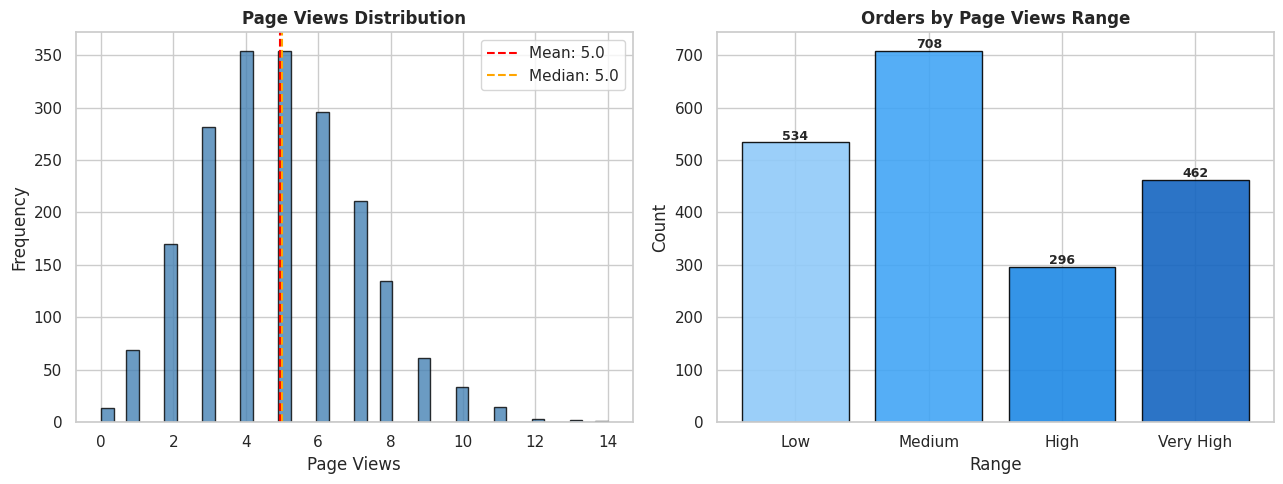

📌 Insight: Mean Page Views = 4.95 | Median = 5.00


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df[metric_col], bins=40, color="steelblue", edgecolor="black", alpha=0.8)
axes[0].axvline(df[metric_col].mean(), color="red", linestyle="--", linewidth=1.5,
                label=f"Mean: {df[metric_col].mean():,.1f}")
axes[0].axvline(df[metric_col].median(), color="orange", linestyle="--", linewidth=1.5,
                label=f"Median: {df[metric_col].median():,.1f}")
axes[0].set_title(f"{metric_col} Distribution", fontweight="bold")
axes[0].set_xlabel(metric_col)
axes[0].set_ylabel("Frequency")
axes[0].legend()

q1 = df[metric_col].quantile(0.25)
q2 = df[metric_col].quantile(0.50)
q3 = df[metric_col].quantile(0.75)
mx = df[metric_col].max()
bins_edges = [df[metric_col].min()-1, q1, q2, q3, mx]
labels_b = ["Low", "Medium", "High", "Very High"]
buckets = pd.cut(df[metric_col], bins=bins_edges, labels=labels_b)
bucket_counts = buckets.value_counts().reindex(labels_b)
bar_colors = ["#90caf9","#42a5f5","#1e88e5","#1565c0"]
bars = axes[1].bar(bucket_counts.index, bucket_counts.values, color=bar_colors, edgecolor="black", alpha=0.9)
axes[1].set_title(f"Orders by {metric_col} Range", fontweight="bold")
axes[1].set_xlabel("Range")
axes[1].set_ylabel("Count")
for bar, val in zip(bars, bucket_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 str(val), ha="center", fontweight="bold", fontsize=9)

plt.tight_layout()
plt.savefig("chart4_pageviews_dist.png", dpi=150)
plt.show()
print(f"📌 Insight: Mean {metric_col} = {df[metric_col].mean():,.2f} | Median = {df[metric_col].median():,.2f}")

### 📈 Chart 5 — Session Duration Analysis

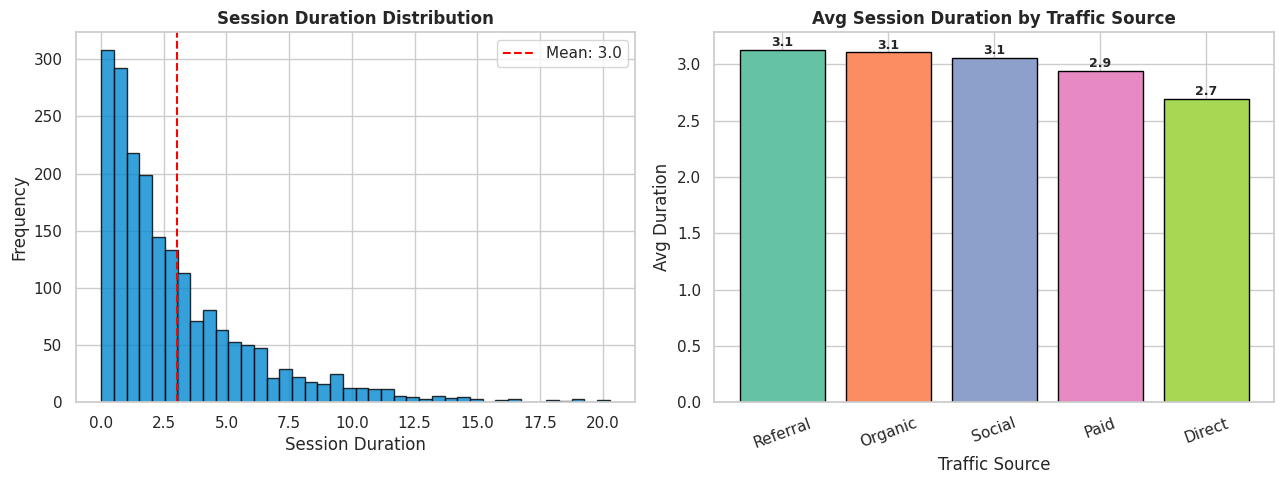

📌 Insight: Avg session duration = 3.02. Higher = more engaged users.


In [17]:
if duration_col:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].hist(df[duration_col], bins=40, color="#0288d1", edgecolor="black", alpha=0.8)
    axes[0].axvline(df[duration_col].mean(), color="red", linestyle="--", linewidth=1.5,
                    label=f"Mean: {df[duration_col].mean():,.1f}")
    axes[0].set_title("Session Duration Distribution", fontweight="bold")
    axes[0].set_xlabel("Session Duration")
    axes[0].set_ylabel("Frequency")
    axes[0].legend()
    dur_by_source = df.groupby(group_col)[duration_col].mean().sort_values(ascending=False)
    axes[1].bar(dur_by_source.index, dur_by_source.values,
                color=sns.color_palette("Set2", len(dur_by_source)), edgecolor="black")
    axes[1].set_title(f"Avg Session Duration by {group_col}", fontweight="bold")
    axes[1].set_xlabel(group_col)
    axes[1].set_ylabel("Avg Duration")
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=20)
    for i, v in enumerate(dur_by_source.values):
        axes[1].text(i, v + max(dur_by_source.values)*0.01, f"{v:,.1f}",
                     ha="center", fontsize=9, fontweight="bold")
    plt.tight_layout()
    plt.savefig("chart5_session_duration.png", dpi=150)
    plt.show()
    print(f"📌 Insight: Avg session duration = {df[duration_col].mean():,.2f}. Higher = more engaged users.")
else:
    print("⚠️ No session duration column found — skipping.")

### 📈 Chart 6 — Conversion Rate by Source

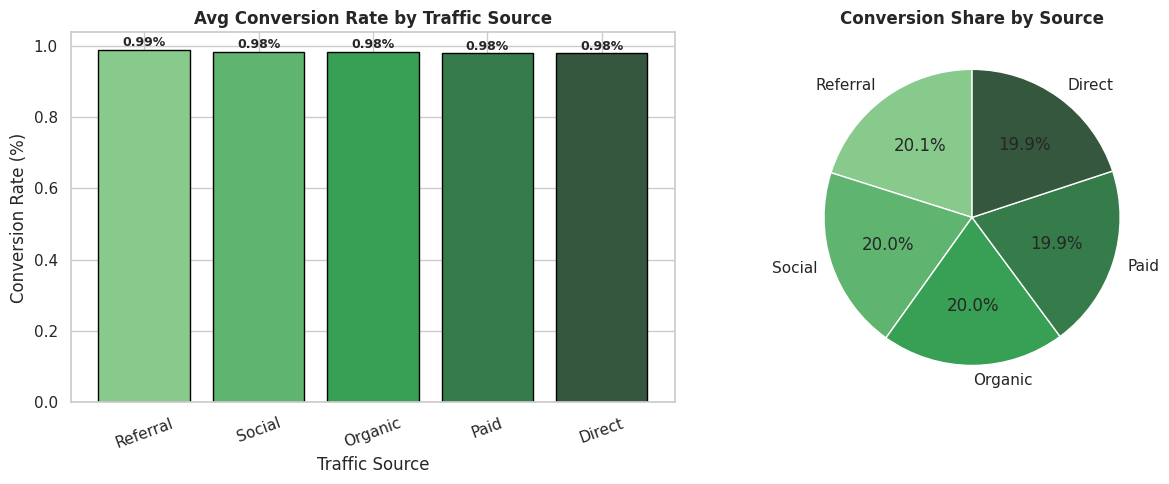

📌 Insight: Best converting source = Referral at 0.99%


In [18]:
if conv_col:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    conv_by_source = df.groupby(group_col)[conv_col].mean().sort_values(ascending=False)
    colors = sns.color_palette("Greens_d", len(conv_by_source))
    axes[0].bar(conv_by_source.index, conv_by_source.values, color=colors, edgecolor="black")
    axes[0].set_title(f"Avg Conversion Rate by {group_col}", fontweight="bold")
    axes[0].set_xlabel(group_col)
    axes[0].set_ylabel("Conversion Rate (%)")
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=20)
    for i, v in enumerate(conv_by_source.values):
        axes[0].text(i, v + max(conv_by_source.values)*0.01, f"{v:.2f}%",
                     ha="center", fontsize=9, fontweight="bold")
    axes[1].pie(conv_by_source.values, labels=conv_by_source.index,
                autopct="%1.1f%%", startangle=90, colors=colors)
    axes[1].set_title("Conversion Share by Source", fontweight="bold")
    plt.tight_layout()
    plt.savefig("chart6_conversion_rate.png", dpi=150)
    plt.show()
    print(f"📌 Insight: Best converting source = {conv_by_source.idxmax()} at {conv_by_source.max():.2f}%")
else:
    print("⚠️ No conversion rate column found — skipping.")

### 📈 Chart 7 — Device / Country Breakdown

In [19]:
if device_col:
    top_vals = df[device_col].value_counts().head(8)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    pal = sns.color_palette("Set3", len(top_vals))
    axes[0].bar(top_vals.index, top_vals.values, color=pal, edgecolor="black")
    axes[0].set_title(f"Sessions by {device_col}", fontweight="bold")
    axes[0].set_xlabel(device_col)
    axes[0].set_ylabel("Count")
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)
    for i, v in enumerate(top_vals.values):
        axes[0].text(i, v + max(top_vals.values)*0.01, str(v),
                     ha="center", fontsize=9, fontweight="bold")
    axes[1].pie(top_vals.values, labels=top_vals.index, autopct="%1.1f%%", startangle=90, colors=pal)
    axes[1].set_title(f"Share by {device_col}", fontweight="bold")
    plt.tight_layout()
    plt.savefig("chart7_device_country.png", dpi=150)
    plt.show()
    print(f"📌 Insight — Top {device_col}:")
    for val, cnt in top_vals.items():
        print(f"   {val}: {cnt} ({cnt/len(df)*100:.1f}%)")
else:
    print("⚠️ No device/country column found — skipping.")

⚠️ No device/country column found — skipping.


### 📈 Chart 8 — Yearly Traffic Growth

In [20]:
if "Year" in df.columns:
    yearly = df.groupby("Year")[metric_col].sum()
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].bar(yearly.index.astype(str), yearly.values,
                color=sns.color_palette("Blues_d", len(yearly)), edgecolor="black")
    axes[0].plot(yearly.index.astype(str), yearly.values,
                 color="red", marker="o", linewidth=2, label="Trend")
    axes[0].set_title(f"Yearly {metric_col} Growth", fontweight="bold")
    axes[0].set_xlabel("Year")
    axes[0].set_ylabel(f"Total {metric_col}")
    for i, v in enumerate(yearly.values):
        axes[0].text(i, v + max(yearly.values)*0.01, f"{v:,.0f}",
                     ha="center", fontweight="bold", fontsize=9)
    axes[0].legend()
    if len(yearly) > 1:
        growth_pct = ((yearly - yearly.shift(1)) / yearly.shift(1) * 100).dropna()
        axes[1].bar(growth_pct.index.astype(str), growth_pct.values,
                    color=["green" if x > 0 else "red" for x in growth_pct.values],
                    edgecolor="black", alpha=0.85)
        axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
        axes[1].set_title("Year-over-Year Growth (%)", fontweight="bold")
        axes[1].set_xlabel("Year")
        axes[1].set_ylabel("Growth (%)")
        for i, v in enumerate(growth_pct.values):
            axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold", fontsize=9)
    else:
        axes[1].text(0.5, 0.5, "Only 1 year of data\nYoY chart not available",
                     ha="center", va="center", transform=axes[1].transAxes, fontsize=12)
    plt.tight_layout()
    plt.savefig("chart8_yearly_growth.png", dpi=150)
    plt.show()
    overall = ((yearly.iloc[-1] - yearly.iloc[0]) / yearly.iloc[0]) * 100
    print(f"📌 Insight: Overall {metric_col} changed by {overall:.1f}%")
else:
    print("⚠️ No year column — skipping yearly growth chart.")

⚠️ No year column — skipping yearly growth chart.


### 📈 Chart 9 — Correlation Heatmap

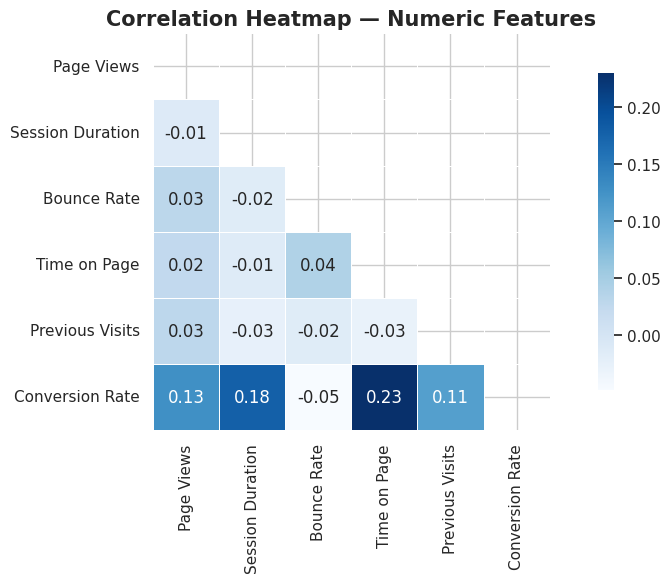

📌 Insight: Strong correlations (close to 1 or -1) indicate related metrics worth investigating.


In [21]:
numeric_df = df.select_dtypes(include="number")
if len(numeric_df.columns) >= 2:
    plt.figure(figsize=(10, 6))
    corr = numeric_df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="Blues",
                linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
    plt.title("Correlation Heatmap — Numeric Features", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.savefig("chart9_correlation_heatmap.png", dpi=150)
    plt.show()
    print("📌 Insight: Strong correlations (close to 1 or -1) indicate related metrics worth investigating.")
else:
    print("⚠️ Not enough numeric columns for heatmap.")

### 📈 Chart 10 — Traffic by Day of Week

In [22]:
if "Day of Week" in df.columns:
    day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
    day_traffic = df.groupby("Day of Week")[metric_col].sum().reindex(day_order).dropna()
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    colors = ["#1565c0" if d not in ["Saturday","Sunday"] else "#0288d1" for d in day_traffic.index]
    axes[0].bar(day_traffic.index, day_traffic.values, color=colors, edgecolor="black")
    axes[0].set_title(f"{metric_col} by Day of Week", fontweight="bold")
    axes[0].set_xlabel("Day")
    axes[0].set_ylabel(f"Total {metric_col}")
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=25)
    for i, v in enumerate(day_traffic.values):
        axes[0].text(i, v + max(day_traffic.values)*0.01, f"{v:,.0f}",
                     ha="center", fontsize=8, fontweight="bold")
    axes[1].pie(day_traffic.values, labels=day_traffic.index, autopct="%1.1f%%",
                startangle=90, colors=sns.color_palette("Set2", 7))
    axes[1].set_title("Traffic Share by Day", fontweight="bold")
    plt.tight_layout()
    plt.savefig("chart10_traffic_by_day.png", dpi=150)
    plt.show()
    best_day = day_traffic.idxmax()
    print(f"📌 Insight: Highest traffic day = {best_day} with {day_traffic[best_day]:,.0f} {metric_col}")
else:
    print("⚠️ No date column — skipping day-of-week chart.")

⚠️ No date column — skipping day-of-week chart.


## 💡 STEP 7 — Key Findings & Business Recommendations

In [23]:
print("=" * 65)
print("        🌐 WEBSITE TRAFFIC ANALYSIS — SUMMARY")
print("=" * 65)

total_traffic = df[metric_col].sum()
avg_traffic   = df[metric_col].mean()
top_source    = df.groupby(group_col)[metric_col].sum().idxmax()
total_records = len(df)

print(f"\n📌 FINDING 1 — Total {metric_col}   : {total_traffic:,.0f}")
print(f"📌 FINDING 2 — Avg per Record       : {avg_traffic:,.2f}")
print(f"📌 FINDING 3 — Total Records        : {total_records:,}")
print(f"📌 FINDING 4 — Top Traffic Source   : {top_source}")

if bounce_col:
    print(f"📌 FINDING 5 — Avg Bounce Rate      : {df[bounce_col].mean():.2f}%")
if conv_col:
    print(f"📌 FINDING 6 — Avg Conversion Rate  : {df[conv_col].mean():.2f}%")
if duration_col:
    print(f"📌 FINDING 7 — Avg Session Duration : {df[duration_col].mean():,.2f}")

print()
print("=" * 65)
print("        💼 BUSINESS RECOMMENDATIONS")
print("=" * 65)
print("""
✅ REC 1: Invest more budget in the top-performing traffic source
✅ REC 2: Reduce bounce rate on high-bounce pages with better content
✅ REC 3: Run campaigns during peak months / peak days for max reach
✅ REC 4: Improve session duration for low-engagement sources
✅ REC 5: A/B test landing pages to boost conversion rates
✅ REC 6: Optimise for mobile if device data shows mobile dominance
✅ REC 7: Target top geographic regions with localised campaigns
""")

        🌐 WEBSITE TRAFFIC ANALYSIS — SUMMARY

📌 FINDING 1 — Total Page Views   : 9,901
📌 FINDING 2 — Avg per Record       : 4.95
📌 FINDING 3 — Total Records        : 2,000
📌 FINDING 4 — Top Traffic Source   : Organic
📌 FINDING 5 — Avg Bounce Rate      : 0.28%
📌 FINDING 6 — Avg Conversion Rate  : 0.98%
📌 FINDING 7 — Avg Session Duration : 3.02

        💼 BUSINESS RECOMMENDATIONS

✅ REC 1: Invest more budget in the top-performing traffic source
✅ REC 2: Reduce bounce rate on high-bounce pages with better content
✅ REC 3: Run campaigns during peak months / peak days for max reach
✅ REC 4: Improve session duration for low-engagement sources
✅ REC 5: A/B test landing pages to boost conversion rates
✅ REC 6: Optimise for mobile if device data shows mobile dominance
✅ REC 7: Target top geographic regions with localised campaigns



## 📥 STEP 8 — Download All Charts

In [24]:
import os
from google.colab import files

charts = [
    "chart1_traffic_by_source.png",
    "chart2_monthly_trend.png",
    "chart3_bounce_rate.png",
    "chart4_pageviews_dist.png",
    "chart5_session_duration.png",
    "chart6_conversion_rate.png",
    "chart7_device_country.png",
    "chart8_yearly_growth.png",
    "chart9_correlation_heatmap.png",
    "chart10_traffic_by_day.png",
]

for chart in charts:
    if os.path.exists(chart):
        files.download(chart)
        print(f"✅ Downloaded: {chart}")
    else:
        print(f"⚠️ Not found (run the chart cell first): {chart}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: chart1_traffic_by_source.png
⚠️ Not found (run the chart cell first): chart2_monthly_trend.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: chart6_conversion_rate.png
⚠️ Not found (run the chart cell first): chart7_device_country.png
⚠️ Not found (run the chart cell first): chart8_yearly_growth.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: chart9_correlation_heatmap.png
⚠️ Not found (run the chart cell first): chart10_traffic_by_day.png


---
## ✅ PROJECT COMPLETE!

### 🚀 Next Steps:
1. **Download this notebook** → File → Download → Download .ipynb
2. **Upload notebook + charts to GitHub**
3. **Submit links on InternSpark**

---
*Project by: [Your Name] | InternSpark Data Analyst Internship*